# Case study: afternoon lifting condensation level from M2HATS radiosondes

The lifting condensation level (LCL) is the height at which air lifted from the surface cools to saturation, which sets the base of any cumulus clouds that form. Over the Nevada desert in summer, dry surface air puts the afternoon LCL several kilometres above the ground.

This notebook calculates the LCL from the surface observation of every afternoon radiosonde launched at the M2HATS ISS1 site and plots how it changed through the campaign. It reads the GDEX copy of the soundings (one NetCDF file per ascent or descent), whose variable names match the ISFS stores, e.g. `air_pressure`, `air_temperature`, `dew_point_temperature`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.units import units

RS_DIR = Path("/lustre/desc1/scratch/myasears/M2HATS/GDEX_datasets/iss1_m2hats_rs41_radiosonde")
ascents = sorted(RS_DIR.glob("*_asc.nc"))
print(f"{len(ascents)} ascents")
xr.open_dataset(ascents[0])

122 ascents


<xarray.Dataset> Size: 399kB
Dimensions:                           (time: 4748, obs: 1)
Coordinates:
  * time                              (time) datetime64[ns] 38kB 2023-07-19T1...
    latitude                          (time) float32 19kB ...
    longitude                         (time) float32 19kB ...
    gps_altitude                      (time) float32 19kB ...
Dimensions without coordinates: obs
Data variables: (12/27)
    trajectory                        |S1 1B ...
    launch_time                       datetime64[ns] 8B ...
    air_pressure                      (time) float32 19kB ...
    air_temperature                   (time) float32 19kB ...
    dew_point_temperature             (time) float32 19kB ...
    relative_humidity                 (time) float32 19kB ...
    ...                                ...
    reference_relative_humidity       (obs) float32 4B ...
    reference_wind_speed              (obs) float32 4B ...
    reference_wind_from_direction     (obs) float32 4B ...
    reference_latitude                (obs) float32 4B ...
    reference_longitude               (obs) float32 4B ...
    reference_altitude                (obs) float32 4B ...
Attributes: (12/51)
    Conventions:                           CF-1.6
    RepoRevision:                          V3.4.7
    RepoLastChangedDate:                   Fri May 6 14:29:37 2022 -0600
    RepoId:                                14c38ba5b54ddaa3e2c5c0669fd4f5b756...
    RepoBranch:                            HEAD
    featureType:                           trajectory
    ...                                    ...
    TrackedSatelliteAverageCount:          11.1
    TrefTemperature:                       /////
    TuTemperature:                         20.28 �C
    UCorrection(Uref1-U1):                 -0.13 %Rh
    Uref1Humidity:                         0.00 %Rh
    history:                               Variables renamed to match the M2H...

## LCL for each afternoon ascent

Afternoon launches are those at 21–22 UTC (14–15 PDT). For each one:
1. Take the surface parcel from the first sample (t = 0), which comes from the reference sensors at the launch site.
2. Calculate the LCL pressure with MetPy's `lcl`.
3. Convert that pressure to a height above the launch site using the sounding's own pressure–altitude profile.

In [2]:
rows = []
for f in ascents:
    with xr.open_dataset(f) as ds:
        if ds.launch_time.dt.hour not in (21, 22):
            continue
        sfc = ds.isel(time=0)
        p_lcl, _ = mpcalc.lcl(sfc.air_pressure.values * units.hPa,
                              sfc.air_temperature.values * units.degC,
                              sfc.dew_point_temperature.values * units.degC)
        prof = ds[["air_pressure", "altitude"]].to_dataframe().dropna().sort_values("air_pressure")
        z_lcl = np.interp(p_lcl.m, prof.air_pressure, prof.altitude)
        rows.append({"launch_time": pd.Timestamp(ds.launch_time.values),
                     "lcl_pressure_hPa": p_lcl.m,
                     "lcl_height_km": (z_lcl - float(sfc.altitude)) / 1e3,
                     "surface_dewpoint_depression_K": float(sfc.air_temperature - sfc.dew_point_temperature)})

lcl = pd.DataFrame(rows).set_index("launch_time")
print(f"{len(lcl)} afternoon soundings")
lcl.describe().round(2)

61 afternoon soundings


,lcl_pressure_hPa,lcl_height_km,surface_dewpoint_depression_K
count,61.00,61.00,61.00
mean,569.06,3.27,26.61
std,64.53,0.92,7.71
min,462.06,0.98,7.80
25%,513.53,2.60,20.90
50%,580.02,3.06,24.90
75%,613.64,4.05,33.10
max,748.86,4.86,40.10


## LCL through the campaign

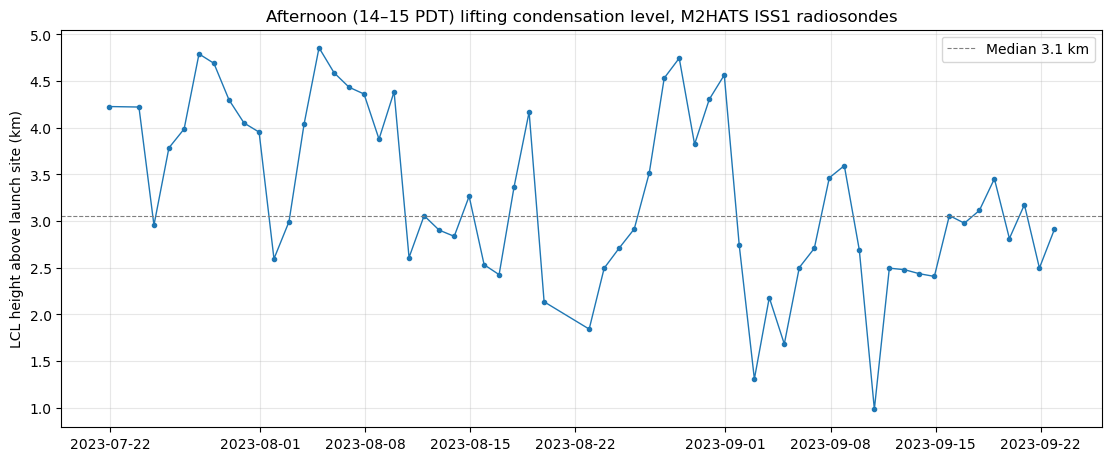

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
ax.plot(lcl.index, lcl.lcl_height_km, marker="o", ms=3, lw=1)
ax.axhline(lcl.lcl_height_km.median(), color="0.5", ls="--", lw=0.8,
           label=f"Median {lcl.lcl_height_km.median():.1f} km")
ax.set(ylabel="LCL height above launch site (km)",
       title="Afternoon (14–15 PDT) lifting condensation level, M2HATS ISS1 radiosondes")
ax.legend(loc="upper right")
ax.grid(alpha=0.3);

As a sanity check, the LCL height is roughly 125 m for every kelvin of surface dew-point depression (Espy's approximation), so the two should track each other closely:

In [4]:
espy_km = 0.125 * lcl.surface_dewpoint_depression_K
print(f"Correlation with 125 m/K × (T − Td): {np.corrcoef(espy_km, lcl.lcl_height_km)[0, 1]:.3f}")
print(f"Median difference (MetPy − Espy): {(lcl.lcl_height_km - espy_km).median() * 1e3:.0f} m")

Correlation with 125 m/K × (T − Td): 1.000
Median difference (MetPy − Espy): -47 m
